# Exercice 2.1 : Partitionnement avec K-Means
Dans cet atelier, nous modifions manuellement le nombre de groupes K pour observer visuellement comment le trafic se sépare.

#### 1. Chargement et normalisation rapide

In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.decomposition import PCA

data = pd.read_csv('data/UNSW_NB15_training-set.csv')
features = data.copy()
for col in features.select_dtypes(include=['object']).columns:
    features[col] = LabelEncoder().fit_transform(features[col].astype(str))
X_scaled = features

# Projection 2D pour visualiser les clusters
X_2d = PCA(n_components=2, random_state=42).fit_transform(X_scaled)
print("Données prêtes :", X_scaled.shape)

C:\Users\Lucas\AppData\Local\Temp\ipykernel_28796\3492284738.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in features.select_dtypes(include=['object']).columns:


Données prêtes : (82332, 45)


#### 2. K-Means avec plusieurs K : Observez la séparation

/home/hp/.local/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
/home/hp/.local/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
/home/hp/.local/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


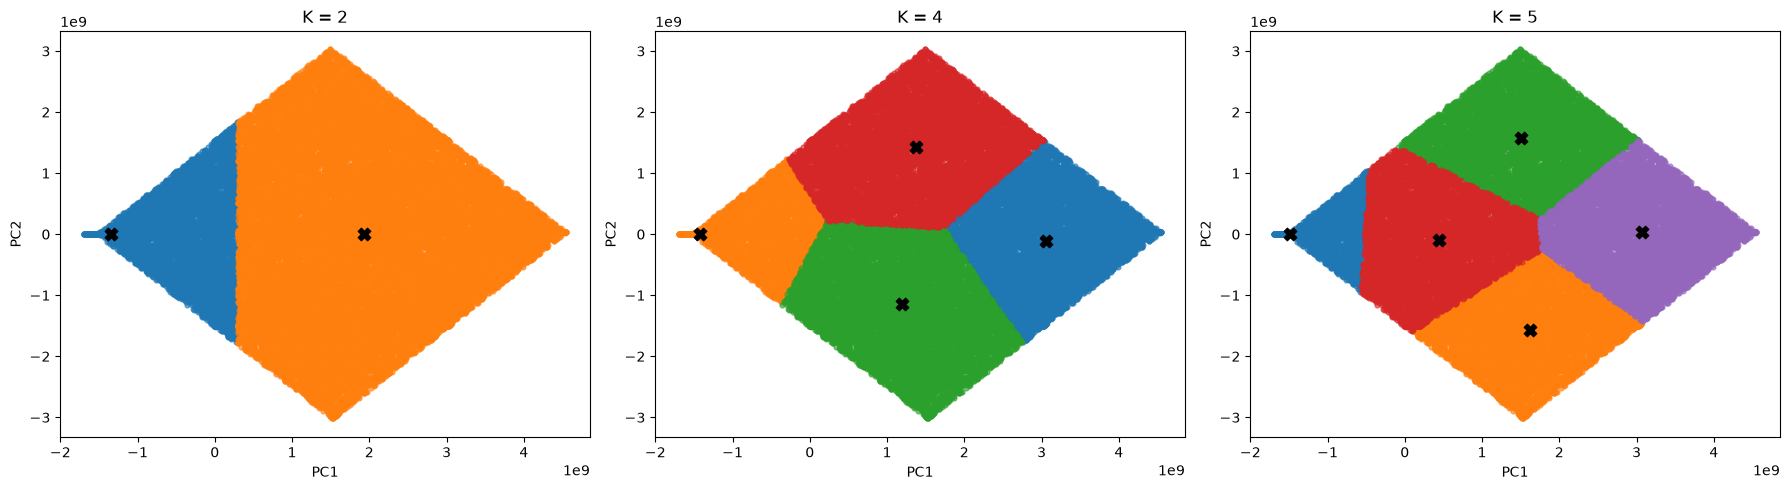

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans

ks = [2, 4, 5]

fig, axes = plt.subplots(1, len(ks), figsize=(18, 5))

for ax, K in zip(axes, ks):
    km = KMeans(n_clusters=K, random_state=42, n_init=10).fit(X_scaled)
    centroids = PCA(n_components=2, random_state=42).fit(X_scaled).transform(km.cluster_centers_)

    for cluster in range(K):
        mask = km.labels_ == cluster
        ax.scatter(
            X_2d[mask, 0],
            X_2d[mask, 1],
            s=12,
            alpha=0.6,
            c=[plt.cm.tab10(cluster % 10)],
        )

    ax.scatter(
        centroids[:, 0],
        centroids[:, 1],
        c='black',
        marker='X',
        s=80,
        label='centroids'
    )
    ax.set_title(f"K = {K}")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.grid(False)

plt.tight_layout()
plt.show()

#### 5. Profilage cyber : Qui sont ces groupes ?

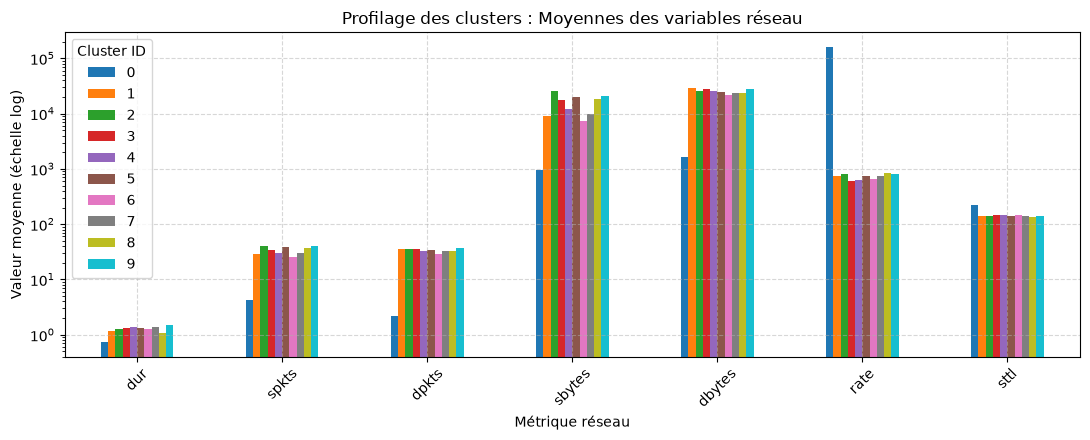

,dur,spkts,dpkts,sbytes,dbytes,rate,sttl
0,0.731515,4.311029,2.154900,974.331892,1625.285701,159623.141145,218.132124
1,1.190249,29.400708,35.768910,9232.584288,28806.996041,734.055217,138.482809
2,1.263030,41.129847,35.442721,25126.719034,25883.547751,816.060465,137.755373
3,1.339146,34.760284,35.237352,17730.599527,27427.181087,609.933705,145.901418
4,1.353548,30.401729,32.859780,12087.216639,25786.566487,621.666814,149.317598
5,1.311050,38.496671,34.356443,19580.416765,24880.285938,732.303103,141.811203
6,1.272130,25.365342,28.901535,7411.901292,21575.254692,652.988773,148.459907
7,1.360311,29.661880,32.107027,9797.349033,23875.474249,740.595892,138.224009
8,1.086744,36.320304,32.912644,18272.020724,23293.998164,858.163425,134.928384
9,1.495758,39.699467,36.762364,20613.237890,27973.672077,801.357735,140.840477


In [9]:
from helper import plot_cluster_profiling

K=5
km = KMeans(n_clusters=K, random_state=42, n_init=10).fit(X_scaled)
# Moyennes des variables clés par groupe
cols = ['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl']
profil = data[cols].groupby(km.labels_).mean()

plot_cluster_profiling(profil)
profil

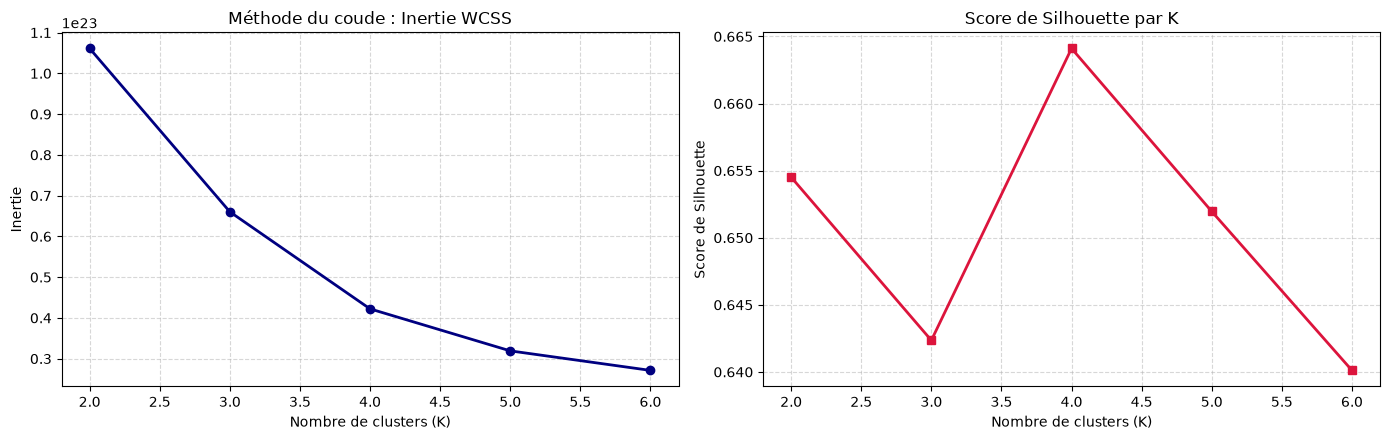

In [10]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from helper import plot_clustering_metrics

k_range = range(2, 7)
inertias, silhouettes = [], []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=5).fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_, sample_size=2000, random_state=42))

plot_clustering_metrics(k_range, inertias, silhouettes)

# À faire :
1. Est-ce que changer standard et robust scaler changent-il le meilleur K? 
2. Extraire les clusters, assigner à chaque ligne sa valeur, et comparer contre les vrais données.

In [16]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, classification_report

# 1. Clustering
km = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = km.fit_predict(X_scaled)
y_true = data["label"].values

# 2. Identifier la vraie classe majoritaire dans le cluster 0
# Si la majorité du cluster 0 est la classe 1, alors les rôles sont inversés
majority_in_cluster_0 = pd.Series(y_true[clusters == 0]).mode()[0]

if majority_in_cluster_0 == 1:
    y_pred = 1 - clusters  # Les rôles étaient inversés
else:
    y_pred = clusters      # Les rôles étaient déjà bons

# 3. Évaluation réelle (reflète la vraie performance, même si elle est mauvaise)
print("Accuracy réelle :", accuracy_score(y_true, y_pred))
print(classification_report(y_true, y_pred, zero_division=0))

Accuracy réelle : 0.6552494777243356
              precision    recall  f1-score   support

           0       0.63      0.57      0.60     37000
           1       0.67      0.72      0.70     45332

    accuracy                           0.66     82332
   macro avg       0.65      0.65      0.65     82332
weighted avg       0.65      0.66      0.65     82332



In [ ]:
import plotly.graph_objects as go
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

K = 3  # Choisir la valeur de K ici

# 1. Calcul PCA 3D
pca = PCA(n_components=3, random_state=42)
X_3d = pca.fit_transform(X_scaled)

# 2. Entraînement K-Means
km = KMeans(n_clusters=K, random_state=42, n_init=10).fit(X_scaled)

# 3. Projection des centroïdes dans le même espace PCA 3D
centroids_3d = pca.transform(km.cluster_centers_)

# 4. Tracé Plotly 3D
fig = go.Figure()

# Points du jeu de données colorés par cluster
fig.add_trace(
    go.Scatter3d(
        x=X_3d[:, 0],
        y=X_3d[:, 1],
        z=X_3d[:, 2],
        mode="markers",
        marker=dict(
            size=3,
            color=km.labels_,
            colorscale="Viridis",
            opacity=0.6,
        ),
        name="Données",
    )
)

# Centroïdes
fig.add_trace(
    go.Scatter3d(
        x=centroids_3d[:, 0],
        y=centroids_3d[:, 1],
        z=centroids_3d[:, 2],
        mode="markers",
        marker=dict(
            size=8,
            color="red",
            symbol="x",
        ),
        name="Centroïdes",
    )
)

fig.update_layout(
    title=f"Clustering K-Means (K = {K}) sur PCA 3D",
    scene=dict(
        xaxis_title=f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f} %)",
        yaxis_title=f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f} %)",
        zaxis_title=f"PC3 ({pca.explained_variance_ratio_[2]*100:.1f} %)",
    ),
    margin=dict(l=0, r=0, b=0, t=40),
)

fig.show()